# H1 — Precio vs Volumen de Ventas

**Hipótesis:** Las categorías de productos con precio promedio más alto presentan
un volumen de ventas significativamente menor que las categorías de bajo precio.

**Herramientas:** PySpark (aggregations, joins) · Matplotlib · Seaborn

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

HDFS         = os.environ.get('HADOOP_NAMENODE', 'hdfs://namenode:8020')
SPARK_MASTER = os.environ.get('SPARK_MASTER', 'local[*]')
DATA_PATH    = f'{HDFS}/data/olist'
OUT          = '/home/jovyan/work/outputs/graficas'
os.makedirs(OUT, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Blues_r')
plt.rcParams['figure.dpi'] = 130

In [2]:
spark = SparkSession.builder \
    .appName('H1_Precio_Volumen') \
    .master(SPARK_MASTER) \
    .config('spark.hadoop.fs.defaultFS', HDFS) \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')
print('Spark listo.')

26/04/17 17:34:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark listo.


In [3]:
items    = spark.read.csv(f'{DATA_PATH}/order_items.csv', header=True, inferSchema=True)
products = spark.read.csv(f'{DATA_PATH}/products.csv',   header=True, inferSchema=True)
orders   = spark.read.csv(f'{DATA_PATH}/orders.csv',     header=True, inferSchema=True)

delivered = orders.filter(F.col('order_status') == 'delivered').select('order_id')

analysis = items \
    .join(delivered, 'order_id') \
    .join(products.select('product_id', 'product_category_name'), 'product_id')

cat_stats = analysis.groupBy('product_category_name').agg(
    F.count('order_item_id').alias('volumen'),
    F.avg('price').alias('precio_promedio'),
    F.sum('price').alias('revenue_total')
).orderBy(F.desc('volumen'))

cat_pd = cat_stats.toPandas()
cat_pd['precio_promedio'] = cat_pd['precio_promedio'].round(2)
print(f'Categorías analizadas: {len(cat_pd)}')
cat_pd.head()

Categorías analizadas: 20


,product_category_name,volumen,precio_promedio,revenue_total
0,alimentos,7800,24.94,194494.18
1,livros,7452,34.78,259157.23
2,papelaria,7084,40.85,289360.61
3,cama_mesa_banho,6709,80.30,538757.74
4,beleza_saude,6109,64.53,394204.77


### Gráfica 1 — Top 15 categorías por volumen

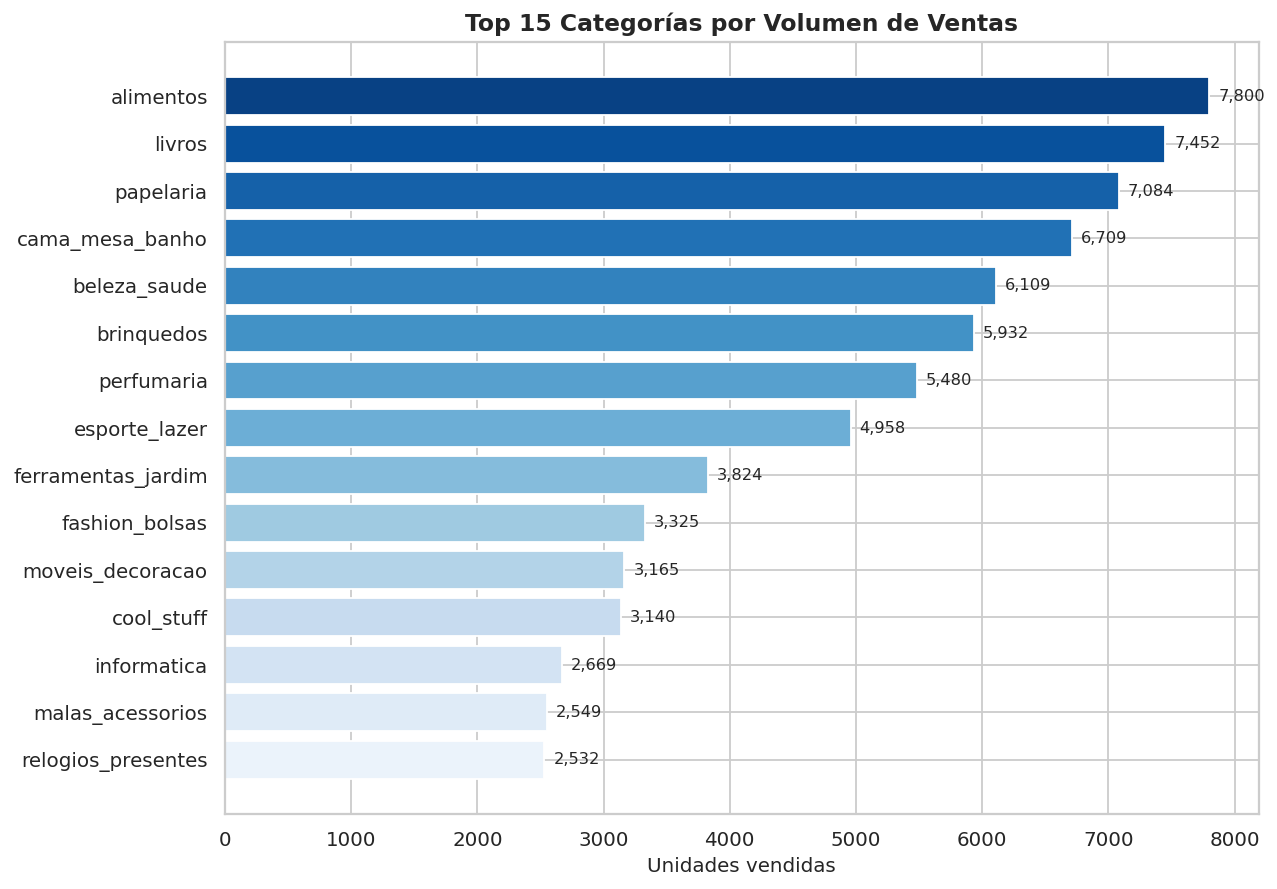

In [4]:
top15  = cat_pd.head(15)
colors = sns.color_palette('Blues_r', 15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['product_category_name'], top15['volumen'], color=colors)
ax.bar_label(bars, labels=[f'{v:,}' for v in top15['volumen']], padding=5, fontsize=9)
ax.set_xlabel('Unidades vendidas', fontsize=11)
ax.set_title('Top 15 Categorías por Volumen de Ventas', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUT}/H1_top15_volumen.png', bbox_inches='tight')
plt.show()

### Gráfica 2 — Dispersión: Precio promedio vs Volumen

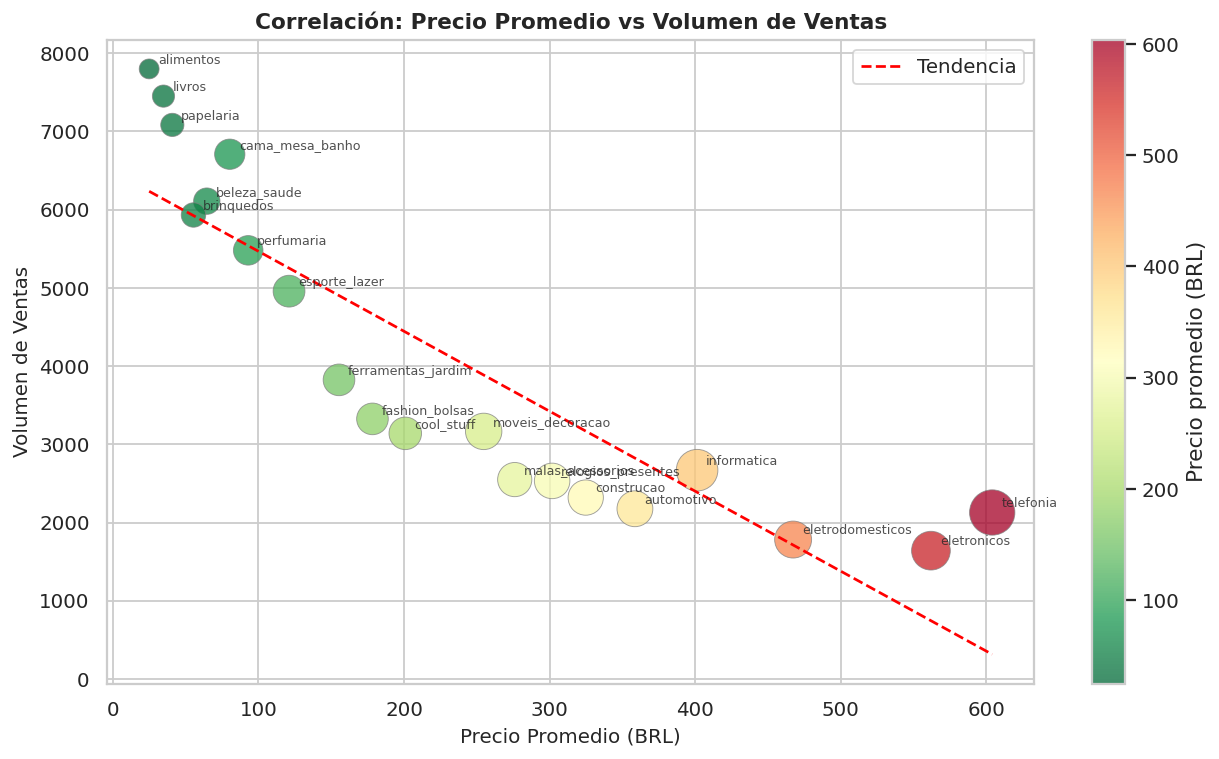

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    cat_pd['precio_promedio'], cat_pd['volumen'],
    s=cat_pd['revenue_total'] / cat_pd['revenue_total'].max() * 600 + 30,
    c=cat_pd['precio_promedio'], cmap='RdYlGn_r',
    alpha=0.75, edgecolors='grey', linewidth=0.5
)
for _, row in cat_pd.iterrows():
    ax.annotate(row['product_category_name'],
                (row['precio_promedio'], row['volumen']),
                textcoords='offset points', xytext=(5, 3), fontsize=7, alpha=0.8)
z = np.polyfit(cat_pd['precio_promedio'], cat_pd['volumen'], 1)
x_line = np.linspace(cat_pd['precio_promedio'].min(), cat_pd['precio_promedio'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.5, label='Tendencia')
plt.colorbar(sc, label='Precio promedio (BRL)')
ax.set_xlabel('Precio Promedio (BRL)', fontsize=11)
ax.set_ylabel('Volumen de Ventas', fontsize=11)
ax.set_title('Correlación: Precio Promedio vs Volumen de Ventas', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT}/H1_scatter_precio_volumen.png', bbox_inches='tight')
plt.show()

### Gráfica 3 — Ventas agrupadas por rango de precio

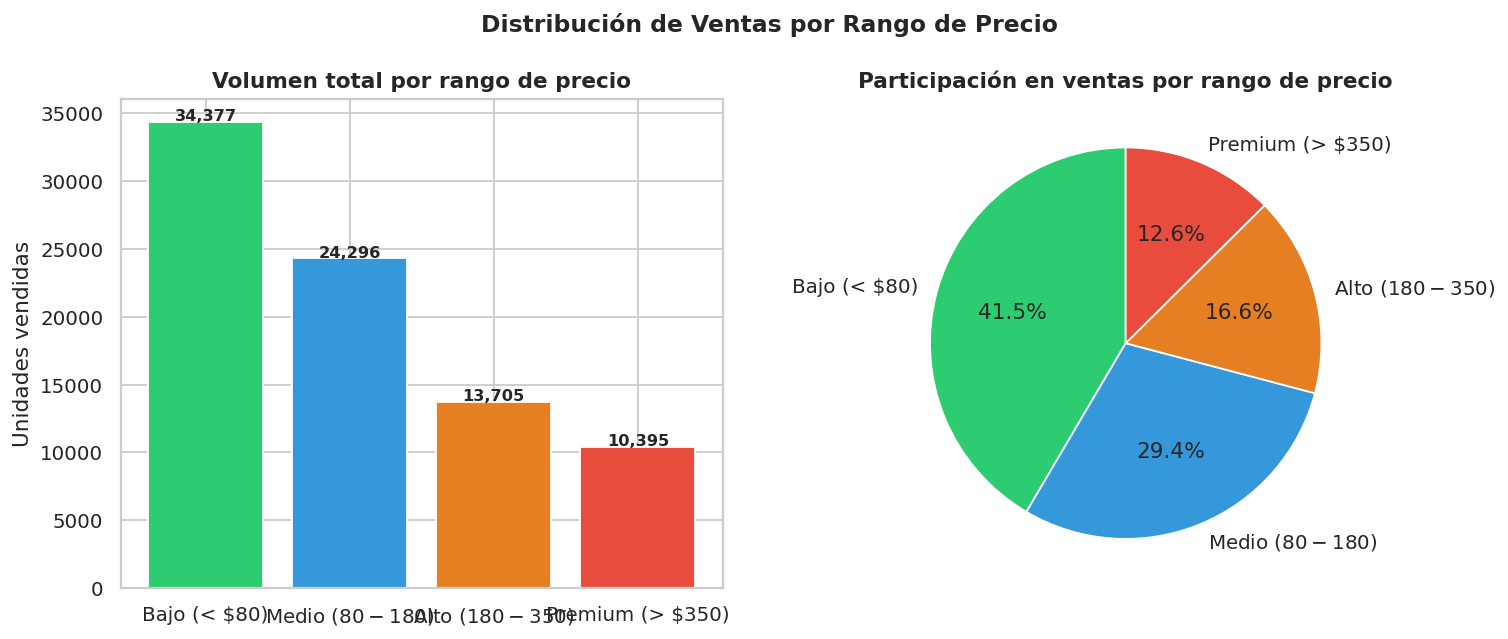

    rango_precio  volumen_total  n_categorias
    Bajo (< $80)          34377             5
Medio ($80-$180)          24296             5
Alto ($180-$350)          13705             5
Premium (> $350)          10395             5


In [6]:
cat_pd['rango_precio'] = pd.cut(
    cat_pd['precio_promedio'],
    bins=[0, 80, 180, 350, 700],
    labels=['Bajo (< $80)', 'Medio ($80-$180)', 'Alto ($180-$350)', 'Premium (> $350)']
)
rango_stats = cat_pd.groupby('rango_precio', observed=True).agg(
    volumen_total=('volumen', 'sum'),
    n_categorias=('product_category_name', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_range = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

axes[0].bar(rango_stats['rango_precio'], rango_stats['volumen_total'],
            color=colors_range, edgecolor='white')
axes[0].set_title('Volumen total por rango de precio', fontweight='bold')
axes[0].set_ylabel('Unidades vendidas')
for i, v in enumerate(rango_stats['volumen_total']):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

axes[1].pie(rango_stats['volumen_total'], labels=rango_stats['rango_precio'],
            colors=colors_range, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Participación en ventas por rango de precio', fontweight='bold')

plt.suptitle('Distribución de Ventas por Rango de Precio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/H1_rangos_precio.png', bbox_inches='tight')
plt.show()
print(rango_stats.to_string(index=False))

### Conclusión H1

In [7]:
corr = cat_pd[['precio_promedio', 'volumen']].corr().iloc[0, 1]
barato  = rango_stats[rango_stats['rango_precio'] == 'Bajo (< $80)']['volumen_total'].values[0]
premium = rango_stats[rango_stats['rango_precio'] == 'Premium (> $350)']['volumen_total'].values[0]
ratio   = barato / premium

print(f'Correlación Precio–Volumen: {corr:.4f}')
print(f'Categorías baratas venden {ratio:.1f}x más que las premium.')
print()
print('CONCLUSIÓN: La hipótesis SE CONFIRMA.')
print(f'  Correlación negativa ({corr:.4f}) confirma relación inversa precio-volumen.')

Correlación Precio–Volumen: -0.8772
Categorías baratas venden 3.3x más que las premium.

CONCLUSIÓN: La hipótesis SE CONFIRMA.
  Correlación negativa (-0.8772) confirma relación inversa precio-volumen.


In [8]:
spark.stop()